# 00 - Análisis exploratorio de datos (EDA)

Exploración de la capa Gold diaria (2021-2025): calidad y cobertura de datos, comportamiento temporal de la generación fotovoltaica, relación con la meteorología y periodos de generación anormalmente baja.

## 1. Carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

gold = pd.read_parquet("../data/gold/gold_diario_2021_2025.parquet")
gold = gold.sort_values("fecha").reset_index(drop=True)

print(gold.shape)
gold.head()

(1825, 16)


,generacion_fotovoltaica,porcentaje_fotovoltaica,fecha,tmed,tmin,tmax,prec,velmedia,racha,hrMedia,presMax,presMin,sol,dia_semana,mes,dia_año
0,34247.163,0.021989,2021-01-02,3.371410,-0.635081,7.377859,0.243681,3.248500,10.651848,66.304925,961.451484,957.727905,6.313311,5,1,2
1,37134.485,0.024855,2021-01-03,3.410448,-1.765693,8.584577,0.232906,2.664880,9.554461,64.446681,962.750448,959.676937,7.293419,6,1,3
2,26307.981,0.017347,2021-01-04,3.357818,-1.088909,7.805587,0.434375,2.175468,8.057505,73.948426,959.948097,956.382750,4.613515,0,1,4
3,29746.352,0.020739,2021-01-05,2.951290,-1.842792,7.745667,0.328913,1.645162,6.131043,74.186674,958.377786,955.568340,5.315905,1,1,5
4,25273.930,0.018880,2021-01-06,2.799222,-2.215370,7.812312,3.824368,1.976831,7.214517,71.192401,959.602209,955.569734,4.533651,2,1,6


## 2. Calidad y cobertura de datos

Valores ausentes, duplicados y valores atípicos en la capa Gold ya integrada.

In [2]:
print("Rango de fechas:", gold["fecha"].min(), "-", gold["fecha"].max())
print("Filas:", gold.shape[0])
print("Fechas duplicadas:", gold["fecha"].duplicated().sum())

print("\nNulos por columna (%):")
print(gold.isna().mean().mul(100).round(2).sort_values(ascending=False))

Rango de fechas: 2021-01-02 00:00:00 - 2025-12-31 00:00:00
Filas: 1825
Fechas duplicadas: 0

Nulos por columna (%):
generacion_fotovoltaica    0.0
porcentaje_fotovoltaica    0.0
fecha                      0.0
tmed                       0.0
tmin                       0.0
tmax                       0.0
prec                       0.0
velmedia                   0.0
racha                      0.0
hrMedia                    0.0
presMax                    0.0
presMin                    0.0
sol                        0.0
dia_semana                 0.0
mes                        0.0
dia_año                    0.0
dtype: float64


In [3]:
variables_numericas = [
    "generacion_fotovoltaica", "tmed", "tmin", "tmax", "prec",
    "velmedia", "racha", "hrMedia", "presMax", "presMin", "sol"
]

gold[variables_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
generacion_fotovoltaica,1825.0,99278.252682,49058.294573,6751.867000,61198.975000,89919.883000,131849.324000,240550.576000
tmed,1825.0,16.415837,6.756323,2.470703,10.761290,15.599088,22.053495,31.221392
tmin,1825.0,10.347652,5.809353,-3.967912,5.609095,9.845407,15.232803,22.299636
tmax,1825.0,22.484516,7.940247,4.997912,15.425997,21.629442,29.148419,40.142503
prec,1825.0,1.486747,2.967031,0.000000,0.031076,0.243572,1.421855,33.041923
velmedia,1825.0,2.655858,0.754777,1.161389,2.154434,2.573798,3.075784,6.726560
racha,1825.0,9.380780,2.168727,4.580144,7.999886,9.219177,10.506159,20.720341
hrMedia,1825.0,59.962399,14.740784,26.722149,46.894559,60.351310,72.520211,90.201357
presMax,1825.0,960.056945,6.786758,937.075095,954.996504,960.284894,964.944837,978.462341
presMin,1825.0,955.953217,7.159495,929.383211,950.799298,956.360061,961.060501,974.257494


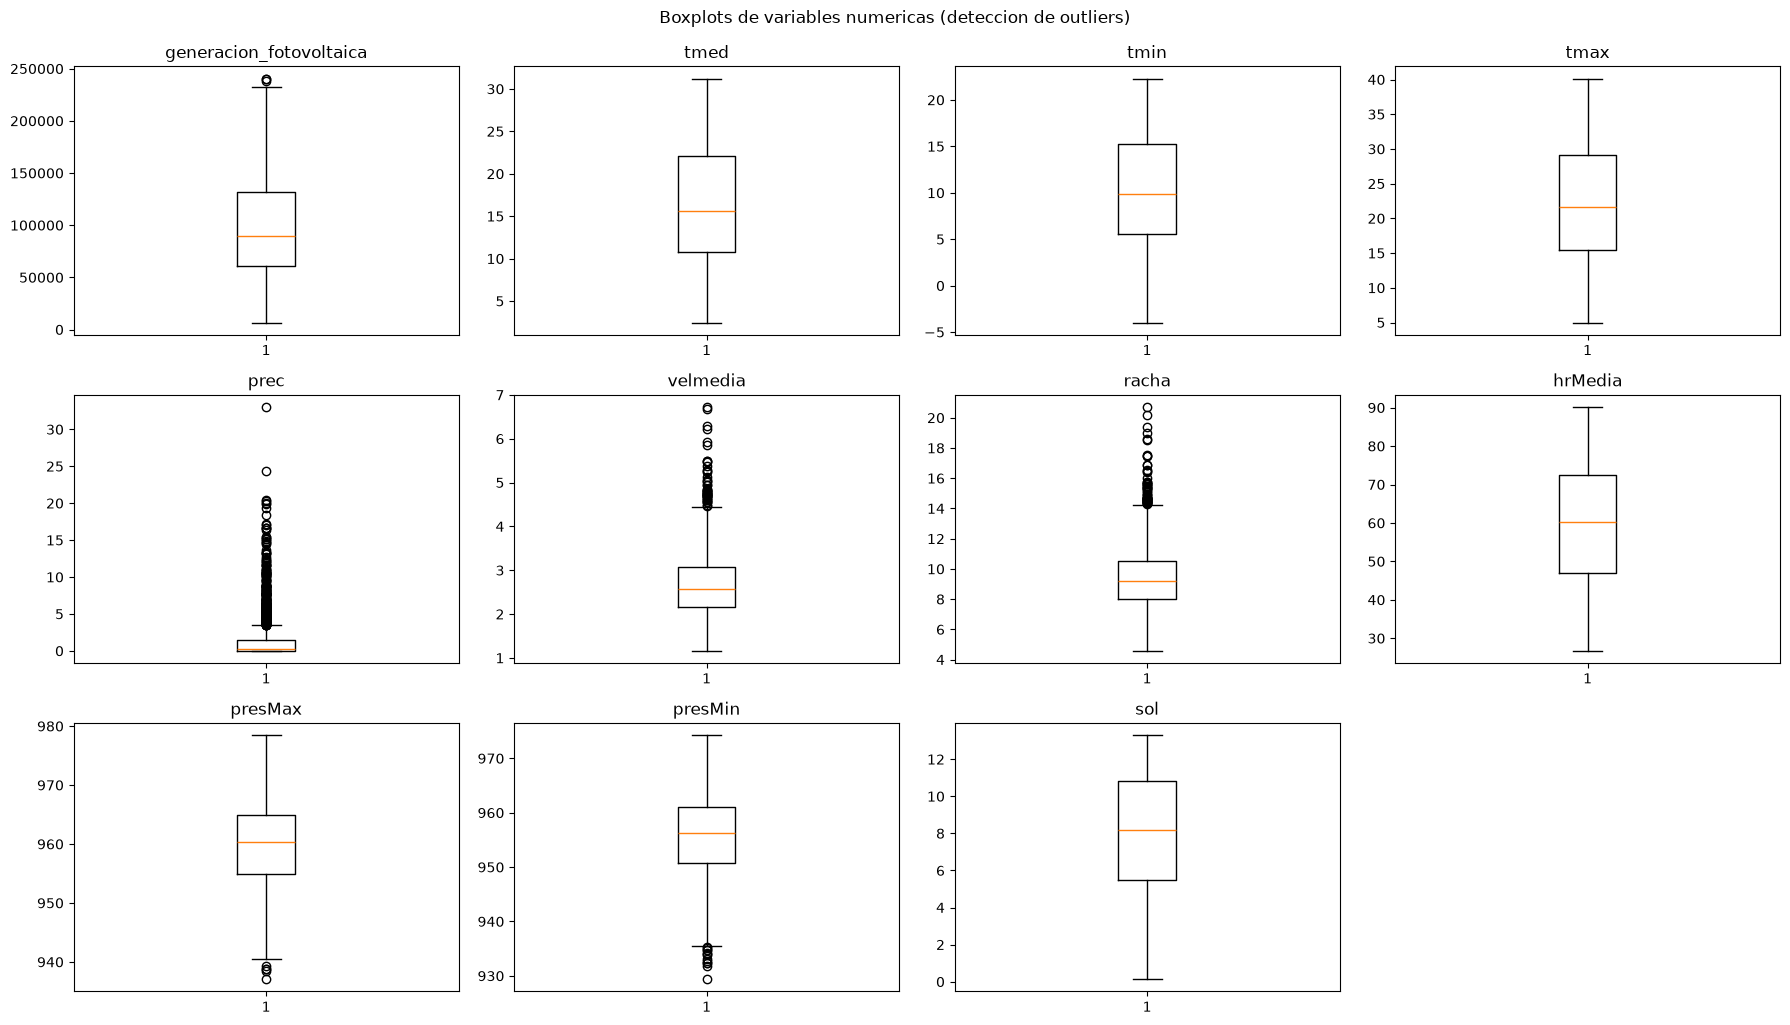

In [4]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(variables_numericas):
    axes[i].boxplot(gold[var].dropna())
    axes[i].set_title(var)

for j in range(len(variables_numericas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Boxplots de variables numericas (deteccion de outliers)", y=1.02)
plt.show()

## 3. Análisis temporal: tendencia y estacionalidad

Evolución de la generación fotovoltaica a lo largo de los 5 años, y patrones estacionales por mes.

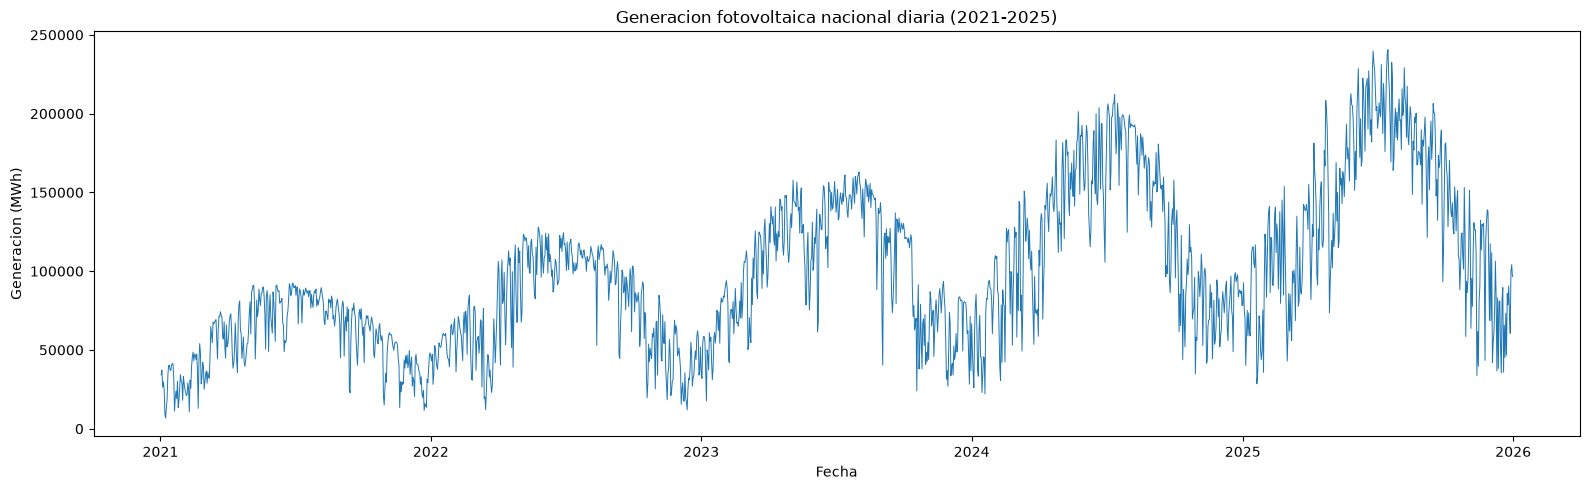

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(gold["fecha"], gold["generacion_fotovoltaica"], linewidth=0.7)
ax.set_title("Generacion fotovoltaica nacional diaria (2021-2025)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Generacion (MWh)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

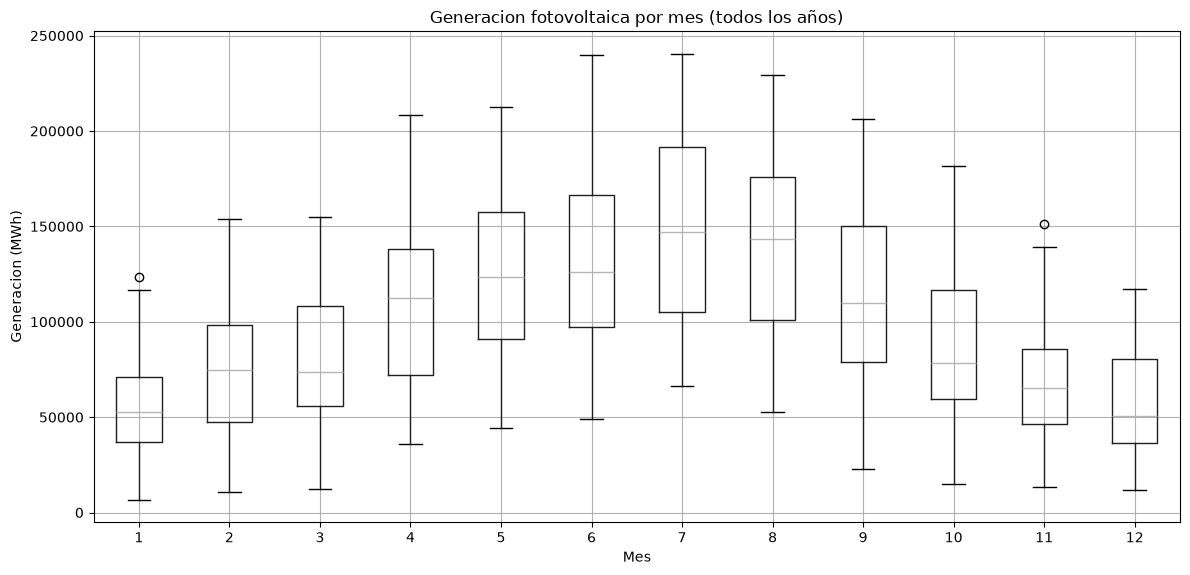

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))
gold.boxplot(column="generacion_fotovoltaica", by="mes", ax=ax)
ax.set_title("Generacion fotovoltaica por mes (todos los años)")
ax.set_xlabel("Mes")
ax.set_ylabel("Generacion (MWh)")
plt.suptitle("")
plt.tight_layout()
plt.show()

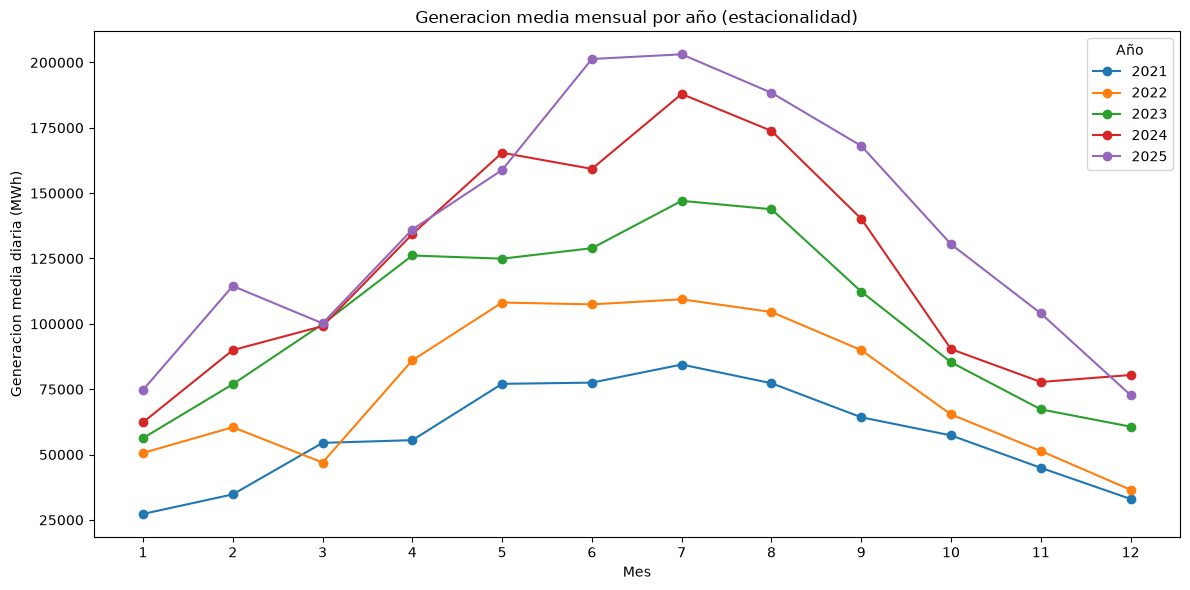

In [7]:
gold["año"] = gold["fecha"].dt.year

media_mensual_por_año = (
    gold.groupby(["año", "mes"])["generacion_fotovoltaica"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
for año, grupo in media_mensual_por_año.groupby("año"):
    ax.plot(grupo["mes"], grupo["generacion_fotovoltaica"], marker="o", label=str(año))

ax.set_title("Generacion media mensual por año (estacionalidad)")
ax.set_xlabel("Mes")
ax.set_ylabel("Generacion media diaria (MWh)")
ax.set_xticks(range(1, 13))
ax.legend(title="Año")
plt.tight_layout()
plt.show()

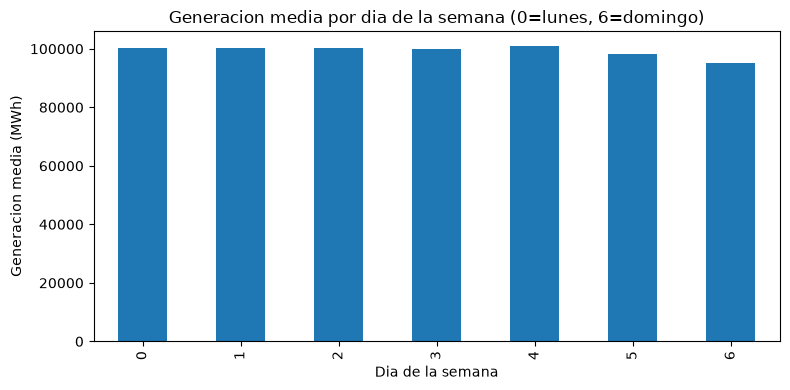

In [ ]:

media_por_dia_semana = (
    gold.groupby("dia_semana")["generacion_fotovoltaica"]
    .mean()
)

fig, ax = plt.subplots(figsize=(8, 4))
media_por_dia_semana.plot(kind="bar", ax=ax)
ax.set_title("Generacion media por dia de la semana (0=lunes, 6=domingo)")
ax.set_xlabel("Dia de la semana")
ax.set_ylabel("Generacion media (MWh)")
plt.tight_layout()
plt.show()

## 4. Relación entre meteorología y generación fotovoltaica

Correlaciones y dispersión entre las variables meteorológicas y la generación.

In [9]:
correlaciones = (
    gold[["generacion_fotovoltaica"] + variables_numericas[1:]]
    .corr()["generacion_fotovoltaica"]
    .drop("generacion_fotovoltaica")
    .sort_values(ascending=False)
)

print(correlaciones)

sol         0.732419
tmax        0.643842
tmed        0.591967
tmin        0.496962
velmedia   -0.081224
racha      -0.092660
presMin    -0.350679
prec       -0.364958
presMax    -0.433872
hrMedia    -0.684178
Name: generacion_fotovoltaica, dtype: float64


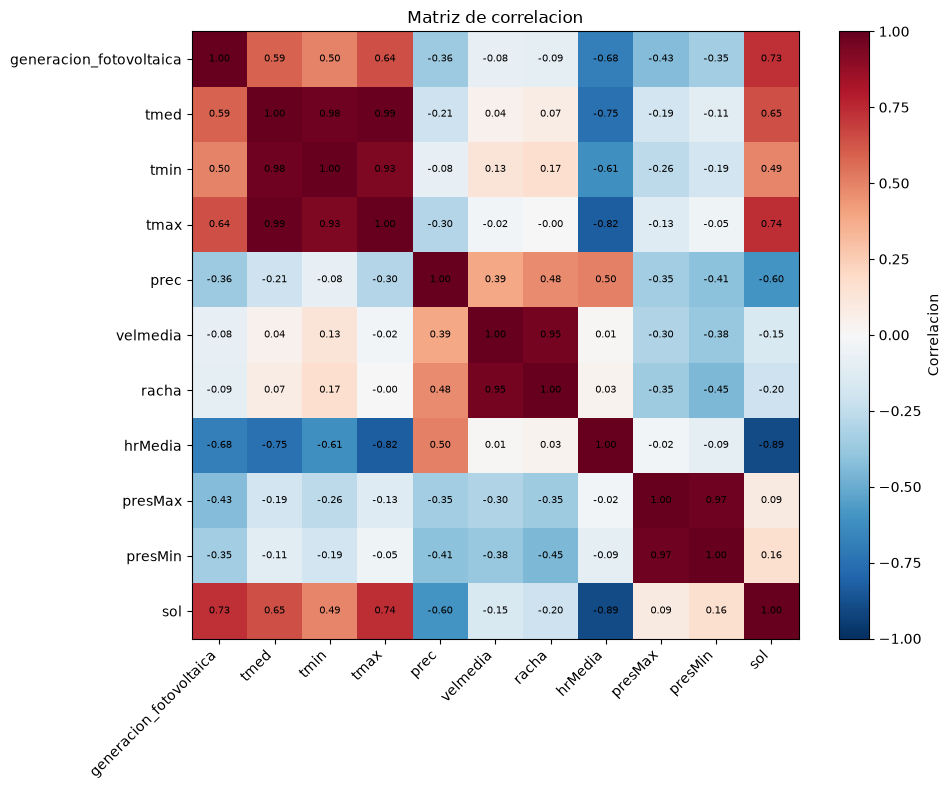

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))
matriz_corr = gold[variables_numericas].corr()
im = ax.imshow(matriz_corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(variables_numericas)))
ax.set_yticks(range(len(variables_numericas)))
ax.set_xticklabels(variables_numericas, rotation=45, ha="right")
ax.set_yticklabels(variables_numericas)

for i in range(len(variables_numericas)):
    for j in range(len(variables_numericas)):
        ax.text(j, i, f"{matriz_corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.colorbar(im, ax=ax, label="Correlacion")
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.show()

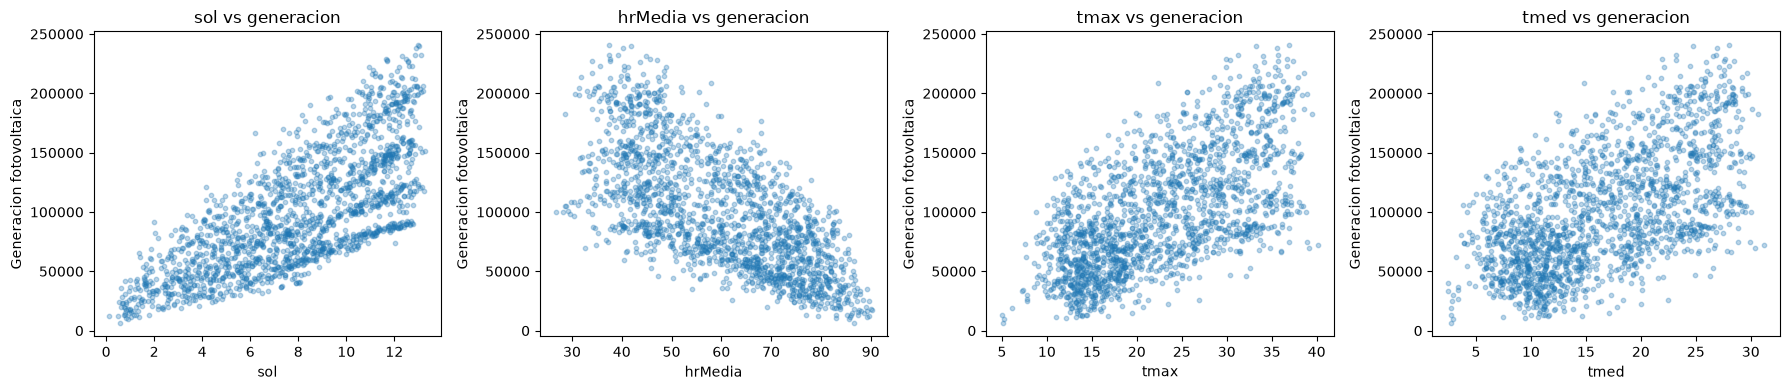

In [11]:
variables_top_correlacion = correlaciones.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(1, len(variables_top_correlacion), figsize=(18, 4))

for ax, var in zip(axes, variables_top_correlacion):
    ax.scatter(gold[var], gold["generacion_fotovoltaica"], alpha=0.3, s=10)
    ax.set_xlabel(var)
    ax.set_ylabel("Generacion fotovoltaica")
    ax.set_title(f"{var} vs generacion")

plt.tight_layout()
plt.show()

## 5. Periodos de generación anormalmente baja

Identificación de días con generación muy por debajo de lo esperable para su época del año, y su relación con condiciones meteorológicas.

In [ ]:

stats_por_mes = (
    gold.groupby("mes")["generacion_fotovoltaica"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "media_mes", "std": "std_mes"})
)

gold = gold.merge(stats_por_mes, on="mes", how="left")
gold["z_score_mensual"] = (
    (gold["generacion_fotovoltaica"] - gold["media_mes"]) / gold["std_mes"]
)

# Umbral: mas de 1.5 desviaciones tipicas por debajo de la media de su mes
# (se relaja de -2 a -1.5 respecto a un primer intento, para tener una muestra
# algo mayor y una comparacion meteorologica mas robusta; con -2 solo salian 3 dias)
umbral = -1.5
dias_baja_generacion = gold[gold["z_score_mensual"] < umbral].sort_values("z_score_mensual")

print("Dias con generacion anormalmente baja:", dias_baja_generacion.shape[0])
dias_baja_generacion[
    ["fecha", "generacion_fotovoltaica", "media_mes", "z_score_mensual",
    "prec", "hrMedia", "sol"]
].head(20)

Dias con generacion anormalmente baja: 90


,fecha,generacion_fotovoltaica,media_mes,z_score_mensual,prec,hrMedia,sol
255,2021-09-14,22826.606,114969.744553,-2.156472,13.433216,78.461888,1.311624
127,2021-05-09,44242.224,126892.461871,-2.113220,5.884412,67.981865,4.849089
254,2021-09-13,25534.977,114969.744553,-2.093087,5.500960,62.095368,1.440970
145,2021-05-27,48993.462,126892.461871,-1.991740,1.207118,58.572766,4.635792
438,2022-03-16,12125.688,80136.171310,-1.985958,4.669545,79.361086,0.135498
6,2021-01-08,6751.867,54427.477266,-1.963857,14.403555,86.662749,0.559273
38,2021-02-09,10786.319,75421.591830,-1.963016,12.217078,83.029868,0.842597
141,2021-05-23,50523.534,126892.461871,-1.952618,8.817387,61.130533,5.041548
301,2021-10-30,15079.026,85751.423129,-1.952501,16.997921,86.146627,0.781901
588,2022-08-13,52832.300,137568.080581,-1.909803,1.032516,45.958586,4.303343


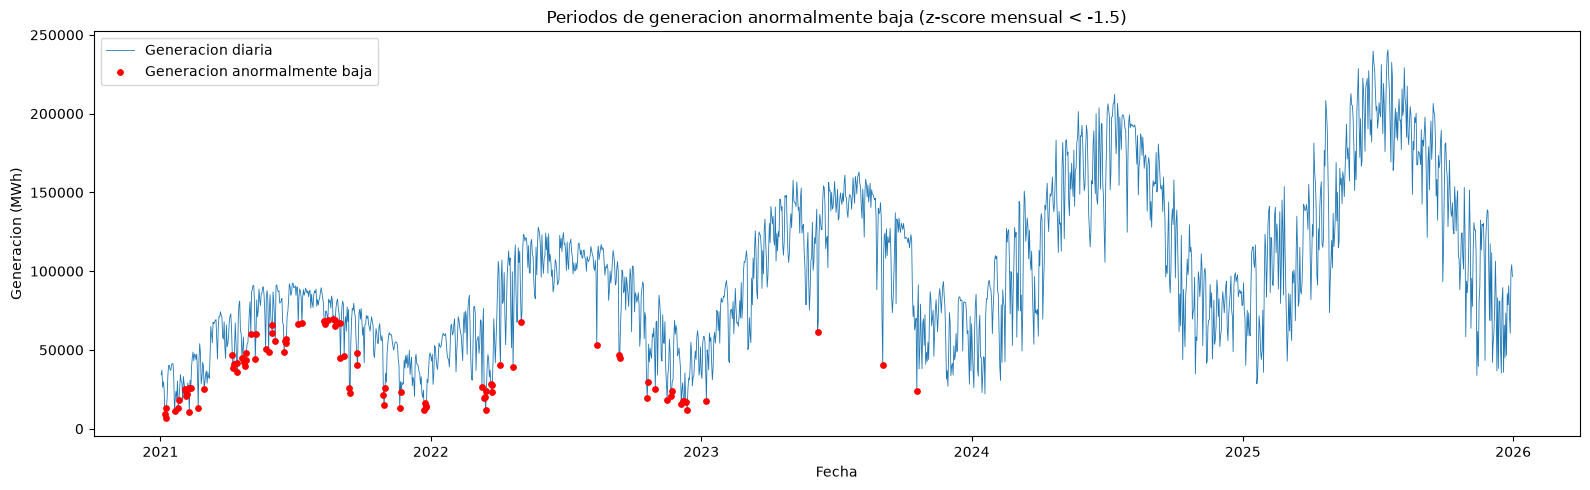

In [13]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(gold["fecha"], gold["generacion_fotovoltaica"], linewidth=0.6, label="Generacion diaria")
ax.scatter(
    dias_baja_generacion["fecha"], dias_baja_generacion["generacion_fotovoltaica"],
    color="red", s=15, zorder=5, label="Generacion anormalmente baja"
)
ax.set_title("Periodos de generacion anormalmente baja (z-score mensual < -1.5)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Generacion (MWh)")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:

comparacion_meteo = pd.DataFrame({
    "media_dias_normales": gold[gold["z_score_mensual"] >= umbral][variables_numericas[1:]].mean(),
    "media_dias_baja_generacion": dias_baja_generacion[variables_numericas[1:]].mean()
})

comparacion_meteo["diferencia"] = (
    comparacion_meteo["media_dias_baja_generacion"] - comparacion_meteo["media_dias_normales"]
)

comparacion_meteo.round(2)

,media_dias_normales,media_dias_baja_generacion,diferencia
tmed,16.48,15.18,-1.30
tmin,10.31,11.12,0.82
tmax,22.65,19.24,-3.41
prec,1.25,6.14,4.89
velmedia,2.63,3.14,0.51
racha,9.29,11.04,1.74
hrMedia,59.24,73.80,14.55
presMax,960.02,960.81,0.79
presMin,955.94,956.19,0.25
sol,8.18,3.39,-4.79


In [15]:
dias_baja_generacion[
    ["fecha", "generacion_fotovoltaica", "media_mes", "z_score_mensual",
    "prec", "hrMedia", "sol", "tmax"]
].to_csv(
    "../data/gold/powerbi_dias_baja_generacion.csv",
    index=False, encoding="utf-8-sig"
)

print("Guardado:", dias_baja_generacion.shape[0], "filas")

Guardado: 90 filas


## 6. Resumen de hallazgos

**Calidad de datos.** No se detectan valores imposibles ni anomalías graves tras la limpieza de `01_limpieza_aemet` y `02_limpieza_ree`. Los outliers presentes en `prec`, `velmedia` y `racha` son físicamente razonables (episodios puntuales de lluvia o viento intensos), no errores de medición.

**La serie no es estacionaria en nivel: hay tendencia de crecimiento, no solo estacionalidad.** La generación media mensual crece de forma marcada año a año — por ejemplo, enero pasa de ~27.000 MWh en 2021 a ~75.000 MWh en 2025, y julio de ~110.000 a ~200.000 MWh — coherente con el fuerte crecimiento de potencia fotovoltaica instalada en España en este periodo. Esto explica a posteriori por qué en `05_modelado` los lags cortos de generación (`lag_1`, `media_7d`), que se adaptan al nivel reciente, funcionan mejor que depender de un patrón estacional fijo por calendario, y por qué el backtesting mostraba mejor rendimiento en las ventanas más recientes.

**No hay efecto de día de la semana**, como cabía esperar: la generación solar no depende del día laborable (variación mínima entre lunes y domingo).

**Las variables meteorológicas con mayor relación con la generación son, por este orden: horas de sol (r=0.73), temperatura máxima (r=0.64), temperatura media (r=0.59) y humedad relativa media (r=-0.68).** Todas con el signo físicamente esperable: más sol y más calor diurno se asocian a mayor generación; más humedad (asociada a mayor nubosidad) se asocia a menor generación.

**Multicolinealidad a documentar como limitación del modelo lineal.** `tmed`, `tmin` y `tmax` están correlacionadas entre sí al 0.93-0.99. Esto es coherente con que, en la importancia de variables de `05_modelado`, `tmax_lag_1` y `tmin_lag_1` aparecieran con signos opuestos y magnitudes grandes pese a estar muy correlacionadas — un síntoma típico de colinealidad en regresión lineal, donde el efecto real se reparte de forma inestable entre variables redundantes.

**Los días de generación anormalmente baja (z-score mensual < -1.5; 90 de 1.825 días, ~4,9% del total, una proporción coherente con lo esperable bajo un supuesto aproximado de normalidad) presentan un patrón meteorológico claro, consistente y físicamente coherente frente a los días normales:** casi 5 veces más precipitación (6,14 mm frente a 1,25 mm), humedad media 14,6 puntos por encima de lo normal (73,8% frente a 59,2%), menos de la mitad de horas de sol (3,39 frente a 8,18) y temperaturas máximas notablemente más bajas para su época del año (19,24°C frente a 22,65°C). Además, la amplitud térmica diaria se reduce (tmin sube ligeramente mientras tmax baja con fuerza), un patrón típico de jornadas nubladas en las que la cobertura de nubes amortigua tanto el calentamiento diurno como el enfriamiento nocturno. En conjunto, describe episodios de paso de frente atmosférico (más viento, más lluvia, menos sol) más que simples días parcialmente nublados. Esto valida empíricamente la hipótesis de partida del proyecto — la meteorología no solo correlaciona con la generación en general, sino que explica de forma consistente los episodios más extremos de baja producción, que son precisamente los más relevantes para el análisis de resiliencia planteado como ampliación futura.